<a href="https://colab.research.google.com/github/saudaahanafi/ai-business-analytics-system/blob/main/Copy_of_AI_Business_Analytics_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Driven Business Analytics and Decision Support System

## Case Studies:
- Moroccan Secrets (Skincare E-Commerce)
- Marwa (Fashion Retail)

### Technologies Used
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Google Colab

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import datetime

# **DATASET GENERATION AND CLEANING**

---



In [4]:


# Moroccan Secrets products
products = {
    "Beldi Soap": {"price": 9500, "cost": 4000, "base_sales": 18},
    "Argan Oil": {"price": 14000, "cost": 7000, "base_sales": 9},
    "Rose Hydrosol": {"price": 8000, "cost": 3000, "base_sales": 14},
    "Aker Fassi": {"price": 8100, "cost": 2500, "base_sales": 7},
    "Tbrima Powder": {"price": 9000, "cost": 3500, "base_sales": 10},
    "Kees Glove": {"price": 9000, "cost": 2000, "base_sales": 12}
}

dates = pd.date_range("2024-01-01", "2024-03-31")

data = []

stock_levels = {
    product: random.randint(70, 150)
    for product in products
}

for date in dates:

    weekend = date.weekday() >= 5

    for product, info in products.items():

        quantity = info["base_sales"]

        # Weekend boost
        if weekend:
            quantity += random.randint(2, 6)

        # Natural fluctuation
        quantity += random.randint(-3, 4)

        # Prevent negative sales
        quantity = max(2, quantity)

        # Simulate demand spikes
        if random.random() < 0.08:
            quantity += random.randint(5, 10)

        revenue = quantity * info["price"]

        # Reduce stock gradually
        stock_levels[product] -= quantity

        # Restock when low
        if stock_levels[product] < 20:
            stock_levels[product] += random.randint(60, 120)

        data.append([
            date.strftime("%Y-%m-%d"),
            product,
            "Skincare",
            info["price"],
            info["cost"],
            quantity,
            revenue,
            stock_levels[product],
            "NGN"
        ])

moroccan_secrets = pd.DataFrame(data, columns=[
    "Date",
    "Product",
    "Category",
    "Price",
    "Cost",
    "Quantity_Sold",
    "Revenue",
    "Stock",
    "Currency"
])

print(moroccan_secrets.head())
print("\nTotal Rows:", len(moroccan_secrets))

moroccan_secrets.to_csv(
    "moroccan_secrets_dataset.csv",
    index=False
)

print("Moroccan Secrets dataset exported successfully.")

         Date        Product  Category  Price  Cost  Quantity_Sold  Revenue  \
0  2024-01-01     Beldi Soap  Skincare   9500  4000             20   190000   
1  2024-01-01      Argan Oil  Skincare  14000  7000             10   140000   
2  2024-01-01  Rose Hydrosol  Skincare   8000  3000             17   136000   
3  2024-01-01     Aker Fassi  Skincare   8100  2500             10    81000   
4  2024-01-01  Tbrima Powder  Skincare   9000  3500             10    90000   

   Stock Currency  
0    100      NGN  
1    121      NGN  
2     72      NGN  
3     62      NGN  
4     81      NGN  

Total Rows: 546
Moroccan Secrets dataset exported successfully.


In [5]:
# Marwa fashion products
products_marwa = {
    "Robe": {"price": 299, "cost": 120, "base_sales": 14},
    "Blazer": {"price": 450, "cost": 200, "base_sales": 6},
    "Jeans": {"price": 250, "cost": 100, "base_sales": 11},
    "T-Shirt": {"price": 120, "cost": 40, "base_sales": 18},
    "Kimonos": {"price": 350, "cost": 150, "base_sales": 7},
    "Skirt": {"price": 180, "cost": 70, "base_sales": 9},
    "Hoodie": {"price": 280, "cost": 110, "base_sales": 10},
    "Cardigan": {"price": 320, "cost": 140, "base_sales": 8}
}

dates_marwa = pd.date_range("2024-01-01", "2024-01-31")

data_marwa = []

stock_levels_marwa = {
    product: random.randint(50, 120)
    for product in products_marwa
}

for date in dates_marwa:

    weekend = date.weekday() >= 5

    for product, info in products_marwa.items():

        quantity = info["base_sales"]

        # Weekend shopping increase
        if weekend:
            quantity += random.randint(3, 7)

        # Daily fluctuations
        quantity += random.randint(-2, 5)

        quantity = max(1, quantity)

        # Fashion spikes
        if random.random() < 0.1:
            quantity += random.randint(4, 9)

        revenue = quantity * info["price"]

        stock_levels_marwa[product] -= quantity

        # Restock
        if stock_levels_marwa[product] < 15:
            stock_levels_marwa[product] += random.randint(40, 90)

        data_marwa.append([
            date.strftime("%Y-%m-%d"),
            product,
            "Clothing",
            info["price"],
            info["cost"],
            quantity,
            revenue,
            stock_levels_marwa[product],
            "MAD"
        ])

marwa = pd.DataFrame(data_marwa, columns=[
    "Date",
    "Product",
    "Category",
    "Price",
    "Cost",
    "Quantity_Sold",
    "Revenue",
    "Stock",
    "Currency"
])

print(marwa.head())
print("\nTotal Rows:", len(marwa))

marwa.to_csv(
    "marwa_dataset.csv",
    index=False
)

print("Marwa dataset exported successfully.")

         Date  Product  Category  Price  Cost  Quantity_Sold  Revenue  Stock  \
0  2024-01-01     Robe  Clothing    299   120             12     3588    107   
1  2024-01-01   Blazer  Clothing    450   200              6     2700     45   
2  2024-01-01    Jeans  Clothing    250   100             14     3500     69   
3  2024-01-01  T-Shirt  Clothing    120    40             21     2520     79   
4  2024-01-01  Kimonos  Clothing    350   150              5     1750     84   

  Currency  
0      MAD  
1      MAD  
2      MAD  
3      MAD  
4      MAD  

Total Rows: 248
Marwa dataset exported successfully.


In [6]:
moroccan_secrets["Month"] = pd.to_datetime(
    moroccan_secrets["Date"]
).dt.month

# February slowdown
feb_mask = moroccan_secrets["Month"] == 2

moroccan_secrets.loc[feb_mask, "Quantity_Sold"] = (
    moroccan_secrets.loc[feb_mask, "Quantity_Sold"] * 0.75
).astype(int)

# Recalculate revenue
moroccan_secrets["Revenue"] = (
    moroccan_secrets["Quantity_Sold"] *
    moroccan_secrets["Price"]
)

In [7]:
moroccan_secrets.to_csv(
    "moroccan_secrets_dataset.csv",
    index=False
)

print("Moroccan Secrets dataset exported successfully.")

marwa.to_csv(
    "marwa_dataset.csv",
    index=False
)

print("Marwa dataset exported successfully.")

Moroccan Secrets dataset exported successfully.
Marwa dataset exported successfully.


In [8]:
from google.colab import files

files.download("moroccan_secrets_dataset.csv")
files.download("marwa_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
moroccan_secrets.info()
moroccan_secrets.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           546 non-null    object
 1   Product        546 non-null    object
 2   Category       546 non-null    object
 3   Price          546 non-null    int64 
 4   Cost           546 non-null    int64 
 5   Quantity_Sold  546 non-null    int64 
 6   Revenue        546 non-null    int64 
 7   Stock          546 non-null    int64 
 8   Currency       546 non-null    object
 9   Month          546 non-null    int32 
dtypes: int32(1), int64(5), object(4)
memory usage: 40.7+ KB


,Price,Cost,Quantity_Sold,Revenue,Stock,Month
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,9600.000000,3666.666667,12.562271,119258.424908,66.428571,2.000000
std,2039.022972,1625.955377,5.024414,49932.036493,29.192047,0.826177
min,8000.000000,2000.000000,3.000000,24300.000000,20.000000,1.000000
25%,8100.000000,2500.000000,9.000000,84000.000000,42.250000,1.000000
50%,9000.000000,3250.000000,12.000000,112000.000000,64.000000,2.000000
75%,9500.000000,4000.000000,16.000000,144000.000000,88.000000,3.000000
max,14000.000000,7000.000000,31.000000,322000.000000,136.000000,3.000000


In [10]:
marwa.info()
marwa.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           248 non-null    object
 1   Product        248 non-null    object
 2   Category       248 non-null    object
 3   Price          248 non-null    int64 
 4   Cost           248 non-null    int64 
 5   Quantity_Sold  248 non-null    int64 
 6   Revenue        248 non-null    int64 
 7   Stock          248 non-null    int64 
 8   Currency       248 non-null    object
dtypes: int64(5), object(4)
memory usage: 17.6+ KB


,Price,Cost,Quantity_Sold,Revenue,Stock
count,248.000000,248.000000,248.000000,248.000000,248.000000
mean,281.125000,116.250000,13.814516,3631.947581,51.975806
std,95.225646,46.173958,5.267526,1412.482256,22.480028
min,120.000000,40.000000,5.000000,1260.000000,15.000000
25%,232.500000,92.500000,10.000000,2520.000000,33.000000
50%,289.500000,115.000000,13.000000,3500.000000,49.000000
75%,327.500000,142.500000,17.250000,4488.750000,69.000000
max,450.000000,200.000000,35.000000,9450.000000,107.000000


# **EXPLORATORY DATA ANALYSIS (EDA)**

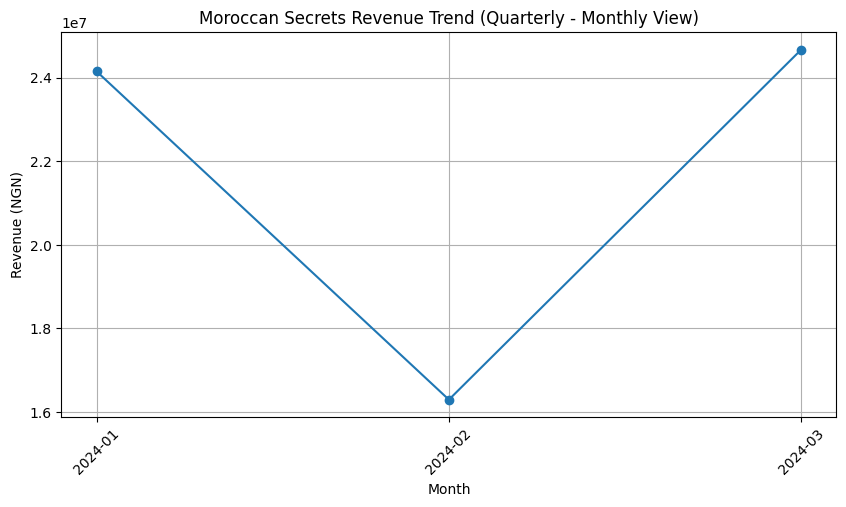

In [11]:
import matplotlib.pyplot as plt

# Ensure Date is datetime
moroccan_secrets["Date"] = pd.to_datetime(moroccan_secrets["Date"])

# Create Month column
moroccan_secrets["Month"] = moroccan_secrets["Date"].dt.to_period("M")

# Group by Month instead of Date
ms_trend = moroccan_secrets.groupby("Month")["Revenue"].sum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(ms_trend.index.astype(str), ms_trend.values, marker="o")


plt.title("Moroccan Secrets Revenue Trend (Quarterly - Monthly View)")
plt.xlabel("Month")
plt.ylabel("Revenue (NGN)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

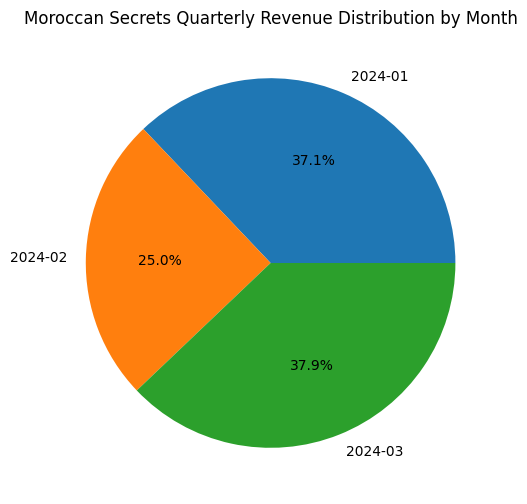

In [12]:
monthly_share = moroccan_secrets.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(6,6))
plt.pie(monthly_share, labels=monthly_share.index.astype(str), autopct="%1.1f%%")

plt.title("Moroccan Secrets Quarterly Revenue Distribution by Month")
plt.show()

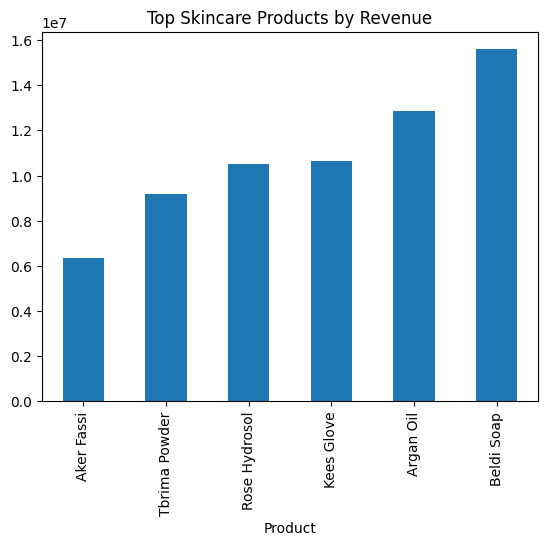

In [13]:
ms_products = moroccan_secrets.groupby("Product")["Revenue"].sum().sort_values()

ms_products.plot(kind="bar")
plt.title("Top Skincare Products by Revenue")
plt.show()

In [14]:
low_stock_ms = moroccan_secrets[moroccan_secrets["Stock"] < 50]
low_stock_ms

,Date,Product,Category,Price,Cost,Quantity_Sold,Revenue,Stock,Currency,Month
14,2024-01-03,Rose Hydrosol,Skincare,8000,3000,16,128000,38,NGN,2024-01
15,2024-01-03,Aker Fassi,Skincare,8100,2500,10,81000,48,NGN,2024-01
17,2024-01-03,Kees Glove,Skincare,9000,2000,18,162000,38,NGN,2024-01
20,2024-01-04,Rose Hydrosol,Skincare,8000,3000,14,112000,24,NGN,2024-01
21,2024-01-04,Aker Fassi,Skincare,8100,2500,6,48600,42,NGN,2024-01
...,...,...,...,...,...,...,...,...,...,...
526,2024-03-28,Tbrima Powder,Skincare,9000,3500,11,99000,35,NGN,2024-03
528,2024-03-29,Beldi Soap,Skincare,9500,4000,24,228000,21,NGN,2024-03
530,2024-03-29,Rose Hydrosol,Skincare,8000,3000,11,88000,42,NGN,2024-03
532,2024-03-29,Tbrima Powder,Skincare,9000,3500,14,126000,21,NGN,2024-03


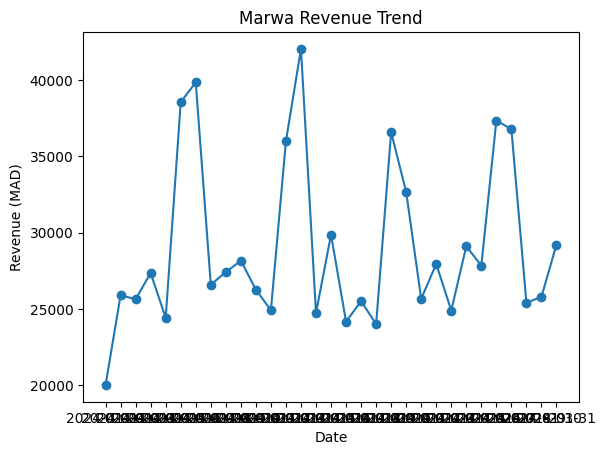

In [15]:
m_revenue = marwa.groupby("Date")["Revenue"].sum()

plt.plot(m_revenue.index, m_revenue.values, marker="o")
plt.title("Marwa Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue (MAD)")
plt.show()

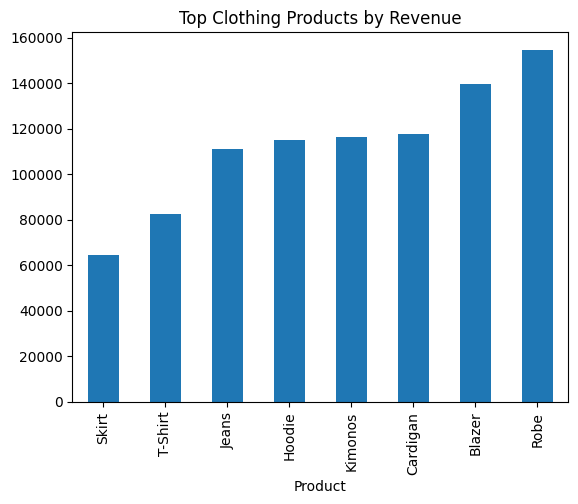

In [16]:
m_products = marwa.groupby("Product")["Revenue"].sum().sort_values()

m_products.plot(kind="bar")
plt.title("Top Clothing Products by Revenue")
plt.show()

In [17]:
low_stock_m = marwa[marwa["Stock"] < 40]
low_stock_m

,Date,Product,Category,Price,Cost,Quantity_Sold,Revenue,Stock,Currency
9,2024-01-02,Blazer,Clothing,450,200,9,4050,36,MAD
15,2024-01-02,Cardigan,Clothing,320,140,11,3520,36,MAD
17,2024-01-03,Blazer,Clothing,450,200,6,2700,30,MAD
19,2024-01-03,T-Shirt,Clothing,120,40,22,2640,34,MAD
23,2024-01-03,Cardigan,Clothing,320,140,13,4160,23,MAD
...,...,...,...,...,...,...,...,...,...
228,2024-01-29,Kimonos,Clothing,350,150,9,3150,22,MAD
231,2024-01-29,Cardigan,Clothing,320,140,11,3520,20,MAD
235,2024-01-30,T-Shirt,Clothing,120,40,21,2520,38,MAD
243,2024-01-31,T-Shirt,Clothing,120,40,19,2280,19,MAD


# **DATA PREPROCESSING**

*Data Preprocessing for Machine Learning*

machine learning pipeline; This step is extremely important because machine learning models cannot understand:text directly, dates directly, messy formats. So we prepare the data properly first.

In [19]:
from sklearn.preprocessing import LabelEncoder

ms_ml = moroccan_secrets.copy()

# Convert dates
ms_ml["Date"] = pd.to_datetime(ms_ml["Date"])

# Extract useful date feature
ms_ml["Day"] = ms_ml["Date"].dt.day

# Encode categorical variables
product_encoder = LabelEncoder()
category_encoder = LabelEncoder()

ms_ml["Product"] = product_encoder.fit_transform(
    ms_ml["Product"]
)

ms_ml["Category"] = category_encoder.fit_transform(
    ms_ml["Category"]
)

# Features
X_ms = ms_ml[
    [
        "Product",
        "Category",
        "Price",
        "Cost",
        "Quantity_Sold",
        "Stock",
        "Day"
    ]
]

# Target
y_ms = ms_ml["Revenue"]

# **MACHINE LEARNING MODELS**

 *Feature Engineering + Train/Test Split:*

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ms = moroccan_secrets.copy()

# Date features
ms["Date"] = pd.to_datetime(ms["Date"])
ms["Day"] = ms["Date"].dt.day
ms["Month"] = ms["Date"].dt.month

# Encode categorical
le_product_ms = LabelEncoder()
le_category_ms = LabelEncoder()

ms["Product"] = le_product_ms.fit_transform(ms["Product"])
ms["Category"] = le_category_ms.fit_transform(ms["Category"])

# Features and target
X_ms = ms[["Product","Category","Price","Cost","Quantity_Sold","Stock","Day","Month"]]
y_ms = ms["Revenue"]

# Split
X_train_ms, X_test_ms, y_train_ms, y_test_ms = train_test_split(
    X_ms,
    y_ms,
    test_size=0.2,
    random_state=42
)
print("Moroccan Secrets ML pipeline ready ✔")

Moroccan Secrets ML pipeline ready ✔


In [21]:
m = marwa.copy()

# Date features
m["Date"] = pd.to_datetime(m["Date"])
m["Day"] = m["Date"].dt.day
m["Month"] = m["Date"].dt.month

# Encode categorical
le_product_m = LabelEncoder()
le_category_m = LabelEncoder()

m["Product"] = le_product_m.fit_transform(m["Product"])
m["Category"] = le_category_m.fit_transform(m["Category"])

# Features and target
X_m = m[["Product","Category","Price","Cost","Quantity_Sold","Stock","Day","Month"]]
y_m = m["Revenue"]

# Split
X_train_ms, X_test_ms, y_train_ms, y_test_ms = train_test_split(
    X_ms,
    y_ms,
    test_size=0.2,
    random_state=42
)
print("Marwa ML pipeline ready ✔")

Marwa ML pipeline ready ✔


Linear Regression Because it is:

excellent for revenue prediction,
simple to explain in defense,
academically appropriate,
perfect for KPI forecasting,

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    accuracy_score
)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train_ms, y_train_ms)

linear_predictions = linear_model.predict(X_test_ms)

linear_r2 = r2_score(
    y_test_ms,
    linear_predictions
)

linear_mae = mean_absolute_error(
    y_test_ms,
    linear_predictions
)

print("LINEAR REGRESSION RESULTS")
print("R2 Score:", linear_r2)
print("MAE:", linear_mae)

LINEAR REGRESSION RESULTS
R2 Score: 0.9781697588628239
MAE: 4139.623053908037


In [24]:
# FEATURES + TARGET
X_ms = moroccan_secrets[["Price", "Cost", "Quantity_Sold", "Stock"]]
y_ms = moroccan_secrets["Revenue"]

# MODEL
ms_model = LinearRegression()
ms_model.fit(X_ms, y_ms)

# PREDICTIONS
ms_pred = ms_model.predict(X_ms)

# EVALUATION
ms_mae = mean_absolute_error(y_ms, ms_pred)
ms_r2 = r2_score(y_ms, ms_pred)

print("=== MOROCCAN SECRETS MODEL ===")
print("MAE:", ms_mae)
print("R2 Score:", ms_r2)

=== MOROCCAN SECRETS MODEL ===
MAE: 4768.933942157278
R2 Score: 0.9746676614315589


In [25]:
# FEATURES + TARGET
X_m = marwa[["Price", "Cost", "Quantity_Sold", "Stock"]]
y_m = marwa["Revenue"]

# MODEL
m_model = LinearRegression()
m_model.fit(X_m, y_m)

# PREDICTIONS
m_pred = m_model.predict(X_m)

# EVALUATION
m_mae = mean_absolute_error(y_m, m_pred)
m_r2 = r2_score(y_m, m_pred)

print("=== MARWA MODEL ===")
print("MAE:", m_mae)
print("R2 Score:", m_r2)

=== MARWA MODEL ===
MAE: 402.88498527256417
R2 Score: 0.852613512836631


 *RANDOM FOREST MODEL| AFTER Linear Regression. | Advanced model comparison.*

*   List item
*   List item



In [26]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_ms, y_train_ms)

rf_predictions = rf_model.predict(X_test_ms)

rf_r2 = r2_score(
    y_test_ms,
    rf_predictions
)

rf_mae = mean_absolute_error(
    y_test_ms,
    rf_predictions
)

print("RANDOM FOREST RESULTS")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)

RANDOM FOREST RESULTS
R2 Score: 0.9900996922254556
MAE: 1213.1090909090908


Random Forest outperformed Linear Regression and was selected as the preferred deployment model.

In [27]:
print("\n=== AI BUSINESS INSIGHTS ===")

# --- Model Performance ---
print("\n--- MODEL PERFORMANCE ---")

if ms_r2 > 0.8:
    print("Moroccan Secrets model: Strong predictive performance.")
else:
    print("Moroccan Secrets model: Needs improvement or more data.")




=== AI BUSINESS INSIGHTS ===

--- MODEL PERFORMANCE ---
Moroccan Secrets model: Strong predictive performance.


In [28]:
print("\n=== AI BUSINESS INSIGHTS ===")

# --- Model Performance ---
print("\n--- MODEL PERFORMANCE ---")

if m_r2 > 0.8:
    print("Marwa model: Strong predictive performance.")
else:
    print("Marwa model: Needs improvement or more data.")



=== AI BUSINESS INSIGHTS ===

--- MODEL PERFORMANCE ---
Marwa model: Strong predictive performance.


In [29]:
# --- Inventory Risk ---
print("\n--- INVENTORY ALERTS ---")

low_stock_ms = moroccan_secrets[moroccan_secrets["Stock"] < 50]

print("\nLow stock clothing items:")
print(low_stock_m[["Product", "Stock"]].drop_duplicates())


--- INVENTORY ALERTS ---

Low stock clothing items:
      Product  Stock
9      Blazer     36
15   Cardigan     36
17     Blazer     30
19    T-Shirt     34
23   Cardigan     23
..        ...    ...
227   T-Shirt     15
228   Kimonos     22
235   T-Shirt     38
243   T-Shirt     19
246    Hoodie     39

[70 rows x 2 columns]


In [30]:
# --- Inventory Risk ---
print("\n--- INVENTORY ALERTS ---")

low_stock_m = marwa[marwa["Stock"] < 40]

print("\nLow stock clothing items:")
print(low_stock_m[["Product", "Stock"]].drop_duplicates())


--- INVENTORY ALERTS ---

Low stock clothing items:
      Product  Stock
9      Blazer     36
15   Cardigan     36
17     Blazer     30
19    T-Shirt     34
23   Cardigan     23
..        ...    ...
227   T-Shirt     15
228   Kimonos     22
235   T-Shirt     38
243   T-Shirt     19
246    Hoodie     39

[70 rows x 2 columns]


**DEMAND** **CLASSIFICATION**

In [31]:
#demand labels
ms_ml["Demand_Level"] = pd.cut(
    ms_ml["Quantity_Sold"],
    bins=[0, 8, 15, 100],
    labels=["Low", "Medium", "High"]
)

#label encoding
demand_encoder = LabelEncoder()

ms_ml["Demand_Level"] = demand_encoder.fit_transform(
    ms_ml["Demand_Level"]
)

#features and targets
X_class = ms_ml[
    [
        "Product",
        "Price",
        "Stock",
        "Day"
    ]
]

y_class = ms_ml["Demand_Level"]

#train test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

#train classifier
classifier = DecisionTreeClassifier(
    random_state=42
)

classifier.fit(X_train_c, y_train_c)

class_predictions = classifier.predict(X_test_c)

accuracy = accuracy_score(
    y_test_c,
    class_predictions
)

print("CLASSIFICATION ACCURACY:", accuracy)

CLASSIFICATION ACCURACY: 0.4636363636363636


In [32]:
# Demand labels
m["Demand_Level"] = pd.cut(
    m["Quantity_Sold"],
    bins=[0, 6, 14, 100],
    labels=["Low", "Medium", "High"]
)

# Encode labels
demand_encoder_m = LabelEncoder()

m["Demand_Level"] = demand_encoder_m.fit_transform(
    m["Demand_Level"]
)

# Features
X_class_m = m[
    [
        "Product",
        "Price",
        "Stock",
        "Day"
    ]
]

# Target
y_class_m = m["Demand_Level"]

# Train-test split
X_train_cm, X_test_cm, y_train_cm, y_test_cm = train_test_split(
    X_class_m,
    y_class_m,
    test_size=0.2,
    random_state=42
)

# Model
classifier_m = DecisionTreeClassifier(
    random_state=42
)

classifier_m.fit(X_train_cm, y_train_cm)

# Predictions
class_predictions_m = classifier_m.predict(X_test_cm)

# Accuracy
accuracy_m = accuracy_score(
    y_test_cm,
    class_predictions_m
)

print("MARWA CLASSIFICATION ACCURACY:", accuracy_m)

MARWA CLASSIFICATION ACCURACY: 0.7


# **DECISION INTELLIGENCE AND BUSINESS RECOMMENDATIONS**

In [33]:
print("MOROCCAN SECRETS AI BUSINESS RECOMMENDATIONS\n")

# Low stock
low_stock = moroccan_secrets[
    moroccan_secrets["Stock"] < 25
]

if not low_stock.empty:
    print("⚠️ Low stock products detected:")
    print(low_stock[["Product", "Stock"]])

# Best sellers
top_products = moroccan_secrets.groupby(
    "Product"
)["Revenue"].sum().sort_values(ascending=False)

top_product = top_products.index[0]

print(f"\n🔥 Promote {top_product} in marketing campaigns.")

# Weak products
weak_products = top_products.sort_values()

weak_product = weak_products.index[0]

print(f"\n💡 Consider discounts for {weak_product}.")

MOROCCAN SECRETS AI BUSINESS RECOMMENDATIONS

⚠️ Low stock products detected:
           Product  Stock
20   Rose Hydrosol     24
33      Aker Fassi     23
61       Argan Oil     20
71      Kees Glove     24
82   Tbrima Powder     24
84      Beldi Soap     24
111     Aker Fassi     21
139      Argan Oil     20
143     Kees Glove     20
148  Tbrima Powder     20
150     Beldi Soap     21
182  Rose Hydrosol     20
196  Tbrima Powder     21
213     Aker Fassi     21
226  Tbrima Powder     22
273     Aker Fassi     20
314  Rose Hydrosol     22
315     Aker Fassi     24
365     Kees Glove     22
376  Tbrima Powder     23
403      Argan Oil     23
417     Aker Fassi     20
444     Beldi Soap     22
451      Argan Oil     22
467     Kees Glove     21
496  Tbrima Powder     20
504     Beldi Soap     23
507     Aker Fassi     20
528     Beldi Soap     21
532  Tbrima Powder     21
536  Rose Hydrosol     23

🔥 Promote Beldi Soap in marketing campaigns.

💡 Consider discounts for Aker Fassi.


In [34]:
print("MARWA AI BUSINESS RECOMMENDATIONS\n")

# Low stock items
low_stock_marwa = marwa[
    marwa["Stock"] < 20
]

if not low_stock_marwa.empty:
    print("⚠️ Low stock clothing items detected:")
    print(low_stock_marwa[["Product", "Stock"]])

# Top products
top_products_marwa = marwa.groupby(
    "Product"
)["Revenue"].sum().sort_values(ascending=False)

top_product_marwa = top_products_marwa.index[0]

print(f"\n🔥 Promote {top_product_marwa} in marketing campaigns.")

# Weak products
weak_products_marwa = top_products_marwa.sort_values()

weak_product_marwa = weak_products_marwa.index[0]

print(f"\n💡 Consider discounts for {weak_product_marwa}.")

MARWA AI BUSINESS RECOMMENDATIONS

⚠️ Low stock clothing items detected:
     Product  Stock
54    Hoodie     17
78    Hoodie     16
100  Kimonos     15
112     Robe     17
153   Blazer     16
166   Hoodie     18
222   Hoodie     16
227  T-Shirt     15
243  T-Shirt     19

🔥 Promote Robe in marketing campaigns.

💡 Consider discounts for Skirt.


In [35]:
print("=== MOROCCAN SECRETS DECISION INTELLIGENCE ===\n")

# Revenue trend
monthly_revenue = moroccan_secrets.groupby("Month")["Revenue"].sum()

if monthly_revenue.iloc[-1] < monthly_revenue.iloc[-2]:
    print("⚠️ Sales may drop next month based on recent trends.")

# Inventory recommendations
low_stock_items = moroccan_secrets[
    moroccan_secrets["Stock"] < 25
]

if not low_stock_items.empty:
    print("\n📦 Recommend stock increase for:")
    print(low_stock_items["Product"].unique())

# Best performing products
best_product = moroccan_secrets.groupby(
    "Product"
)["Revenue"].sum().idxmax()

print(f"\n🔥 Recommend promoting {best_product} in advertisements.")

# High value products
high_value = moroccan_secrets.groupby(
    "Product"
)["Revenue"].mean().idxmax()

print(f"\n💎 Customer segment identified: High-value buyers prefer {high_value}.")

=== MOROCCAN SECRETS DECISION INTELLIGENCE ===


📦 Recommend stock increase for:
['Rose Hydrosol' 'Aker Fassi' 'Argan Oil' 'Kees Glove' 'Tbrima Powder'
 'Beldi Soap']

🔥 Recommend promoting Beldi Soap in advertisements.

💎 Customer segment identified: High-value buyers prefer Beldi Soap.


In [36]:
print("=== MARWA DECISION INTELLIGENCE ===\n")

# Revenue trends
marwa["Month"] = pd.to_datetime(marwa["Date"]).dt.month

monthly_revenue_m = marwa.groupby("Month")["Revenue"].sum()

if monthly_revenue_m.iloc[-1] < monthly_revenue_m.iloc[0]:
    print("⚠️ Clothing sales show signs of decline.")

# Inventory alerts
low_stock_marwa = marwa[
    marwa["Stock"] < 20
]

if not low_stock_marwa.empty:
    print("\n📦 Recommend restocking:")
    print(low_stock_marwa["Product"].unique())

# Strongest products
best_product_m = marwa.groupby(
    "Product"
)["Revenue"].sum().idxmax()

print(f"\n🔥 Recommend promoting {best_product_m} during weekend campaigns.")

# Customer insight
high_value_m = marwa.groupby(
    "Product"
)["Revenue"].mean().idxmax()

print(f"\n💎 High-value customers are strongly associated with {high_value_m}.")

=== MARWA DECISION INTELLIGENCE ===


📦 Recommend restocking:
['Hoodie' 'Kimonos' 'Robe' 'Blazer' 'T-Shirt']

🔥 Recommend promoting Robe during weekend campaigns.

💎 High-value customers are strongly associated with Robe.


**FINAL AI INSIGHTS**

In [37]:
print("=== MOROCCAN SECRETS FINAL BUSINESS INSIGHTS ===\n")

print("1. February recorded weaker sales performance compared to January and March.")

print("2. Beldi Soap consistently generated the highest revenue and remained the strongest-performing skincare product.")

print("3. Inventory shortages were detected for some skincare items, indicating restocking needs.")

print("4. Random Forest produced more accurate revenue predictions than Linear Regression.")

print("5. The demand classification model successfully categorized products into low, medium, and high demand groups.")

print("6. The system identified fluctuating demand patterns and simulated business disruptions effectively.")

=== MOROCCAN SECRETS FINAL BUSINESS INSIGHTS ===

1. February recorded weaker sales performance compared to January and March.
2. Beldi Soap consistently generated the highest revenue and remained the strongest-performing skincare product.
3. Inventory shortages were detected for some skincare items, indicating restocking needs.
4. Random Forest produced more accurate revenue predictions than Linear Regression.
5. The demand classification model successfully categorized products into low, medium, and high demand groups.
6. The system identified fluctuating demand patterns and simulated business disruptions effectively.


In [38]:
print("=== MARWA FINAL BUSINESS INSIGHTS ===\n")

print("1. T-Shirts and Robes showed consistently strong sales performance throughout the month.")

print("2. Blazers generated high unit value but lower sales volume compared to fast-moving fashion items.")

print("3. Inventory risks were detected for selected clothing products with declining stock levels.")

print("4. The machine learning models successfully predicted revenue trends for clothing products.")

print("5. The demand classification system identified differences between high-demand and low-demand fashion items.")

print("6. Weekend periods showed increased customer purchasing activity across several clothing categories.")

=== MARWA FINAL BUSINESS INSIGHTS ===

1. T-Shirts and Robes showed consistently strong sales performance throughout the month.
2. Blazers generated high unit value but lower sales volume compared to fast-moving fashion items.
3. Inventory risks were detected for selected clothing products with declining stock levels.
4. The machine learning models successfully predicted revenue trends for clothing products.
5. The demand classification system identified differences between high-demand and low-demand fashion items.
6. Weekend periods showed increased customer purchasing activity across several clothing categories.


In [39]:
top_product = moroccan_secrets.groupby(
    "Product"
)["Revenue"].sum().idxmax()

print(f"Top performing product: {top_product}")

Top performing product: Beldi Soap


In [40]:
top_product = marwa.groupby(
    "Product"
)["Revenue"].sum().idxmax()

print(f"Top performing product: {top_product}")

Top performing product: Robe
